# Air quality

### Importing dataset

In [ ]:
import pandas as pd
df = pd.read_csv("air1.csv")

### Data cleaning and manipulation

In [ ]:
df = df.drop(columns=["Message"])
df.columns = ["id", "pollutant_code", "pollutant", "measure_type", "unit",
              "cd_code", "location_code", "location", "period", "start_date", "value"]
print(df.head())

       id  pollutant_code               pollutant measure_type unit cd_code  \
0  336867             375  Nitrogen dioxide (NO2)         Mean  ppb      CD   
1  336741             375  Nitrogen dioxide (NO2)         Mean  ppb      CD   
2  550157             375  Nitrogen dioxide (NO2)         Mean  ppb      CD   
3  412802             375  Nitrogen dioxide (NO2)         Mean  ppb      CD   
4  412803             375  Nitrogen dioxide (NO2)         Mean  ppb      CD   

   location_code                           location               period  \
0            407      Flushing and Whitestone (CD7)       Winter 2014-15   
1            107              Upper West Side (CD7)       Winter 2014-15   
2            414  Rockaway and Broad Channel (CD14)  Annual Average 2017   
3            407      Flushing and Whitestone (CD7)       Winter 2015-16   
4            407      Flushing and Whitestone (CD7)          Summer 2016   

  start_date  value  
0  12/1/2014  23.97  
1  12/1/2014  27.42  
2 

In [ ]:
df["date"] = pd.to_datetime(df["start_date"], errors="coerce")
df["value"] = pd.to_numeric(df["value"], errors="coerce")


In [ ]:
missing = df.isna().sum()
print(missing)

id                0
pollutant_code    0
pollutant         0
measure_type      0
unit              0
cd_code           0
location_code     0
location          0
period            0
start_date        0
value             0
date              0
dtype: int64


In [ ]:
before = df.shape[0]

df = df.dropna()

after = df.shape[0]
dropped = before - after

print(f"Rows dropped: {dropped}")


Rows dropped: 0


This code calculates how many rows were removed from the DataFrame after dropping all rows containing missing values (NaN). It helps to understand the impact of cleaning the dataset on its size.
Since the output was 0, it means that there were no rows with missing values in the DataFrame, so no rows were dropped during the `dropna()` operation.

In [ ]:
df["year"] = df["period"].str.extract(r"(\d{4})").astype(int)

df["season"] = df["period"].str.extract(r"(Winter|Summer|Annual)", expand=False)

print(df[["period", "year", "season"]].head())

                period  year  season
0       Winter 2014-15  2014  Winter
1       Winter 2014-15  2014  Winter
2  Annual Average 2017  2017  Annual
3       Winter 2015-16  2015  Winter
4          Summer 2016  2016  Summer


This code extracts specific year and season from a time perios, which will be useful in further analysis.

In [ ]:
df["pollutant"] = df["pollutant"].str.replace("Fine particles \\(PM 2.5\\)", "PM2.5", regex=True)
df["pollutant"] = df["pollutant"].str.replace("Nitrogen dioxide \\(NO2\\)", "NO2", regex=True)

In [ ]:
pm25_only = df[df["pollutant"] == "PM2.5"]
no2_only = df[df["pollutant"] == "NO2"]

In [ ]:
selected_pollutants = [
    'NO2', 'PM2.5', 'Boiler Emissions - Total SO2 Emissions', 'Ozone (O3)',
    'Boiler Emissions - Total NOx Emissions', 'Boiler Emissions - Total PM2.5 Emissions',
    'Outdoor Air Toxics - Formaldehyde', 'Outdoor Air Toxics - Benzene',
]

pollutants_df = df[df['pollutant'].isin(selected_pollutants)]


selected_plot_df = pollutants_df[['pollutant', 'year', 'value', 'location_code']].copy()

Creating a dataframe containing specifically different pollutants.

In [ ]:
seasonal_pollutants = [
    'NO2', 'PM2.5',
]

seasonal_df = df[df['pollutant'].isin(seasonal_pollutants)]

seasonal_plot_df = seasonal_df[['pollutant', 'season', 'value', 'year']].copy()

Creating a df with seasonal pollutants, we only have seasonal measurements for no2 and pm2.5
Ozone has measurements only for summer

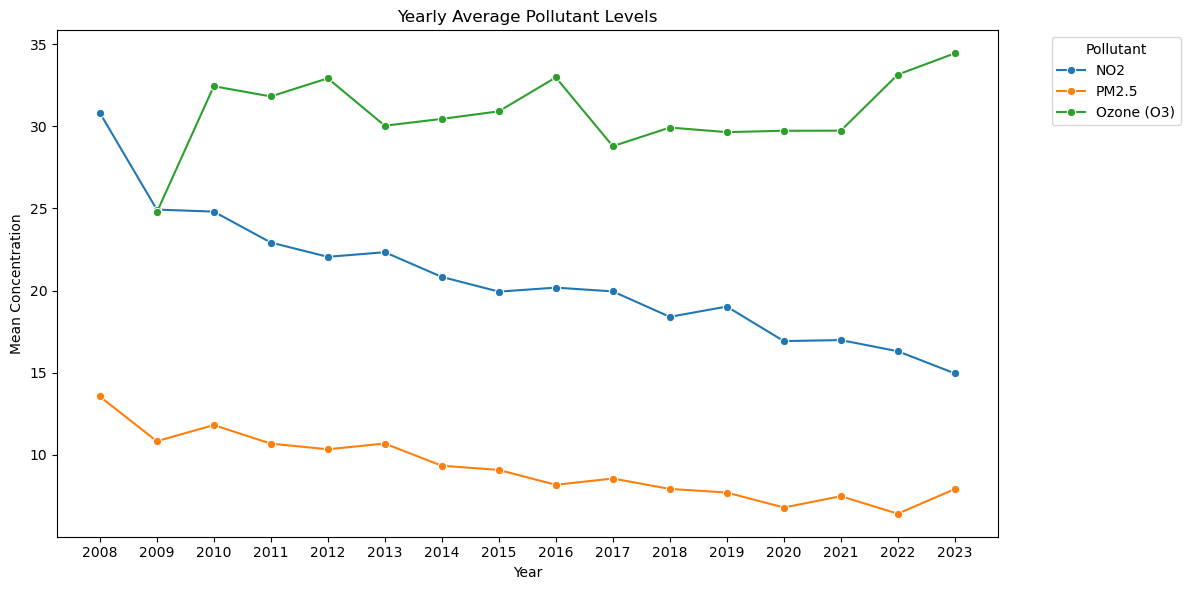

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

toxics = ['Outdoor Air Toxics - Formaldehyde', 'Outdoor Air Toxics - Benzene']

filtered_df = selected_plot_df[
    (selected_plot_df['year'] >= 2008) &
    (~selected_plot_df['pollutant'].isin(toxics))
]

grouped = filtered_df.groupby(['year', 'pollutant'])['value'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=grouped, x='year', y='value', hue='pollutant', marker='o')
plt.title("Yearly Average Pollutant Levels")
plt.xlabel("Year")
plt.ylabel("Mean Concentration")
plt.legend(title='Pollutant', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(sorted(grouped['year'].unique()))
plt.tight_layout()
plt.show()


This line graph offers a clear depiction of yearly average pollutant levels from 2008 to 2023, showcasing distinct trends for each substance. We can observe a consistent and encouraging downward trend in NO2 concentrations across the entire period. Similarly, PM2.5 levels, while experiencing minor fluctuations, also show a general decreasing trend from their initial values in 2008 to 2023. In contrast, a significant area of concern arises with Ozone (O3) levels, which exhibit notable variability but ultimately display a worrying upward trajectory in recent years, culminating in O3 becoming the highest concentration pollutant by 2023. 

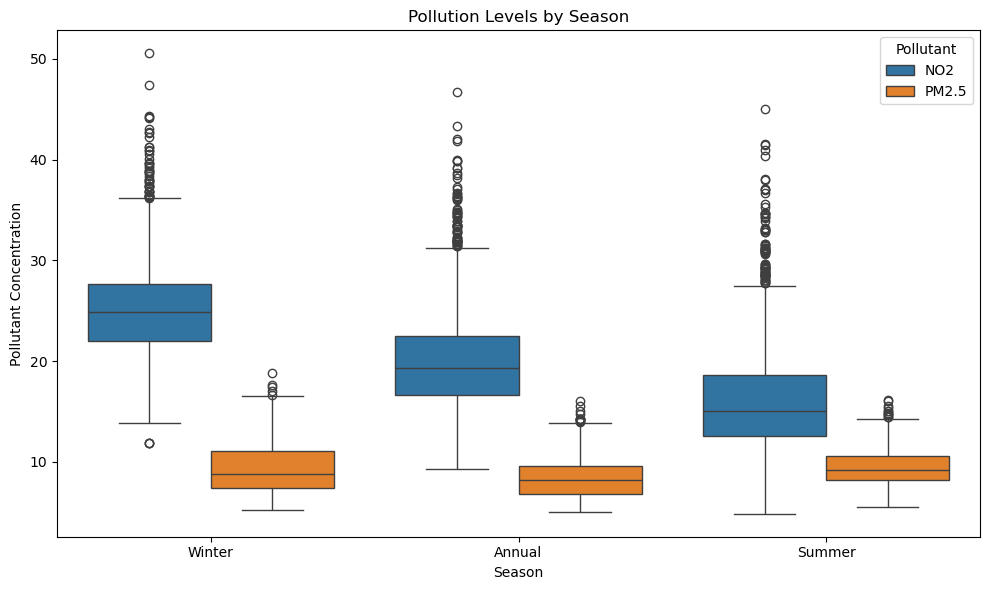

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(data=seasonal_plot_df, x="season", y="value", hue="pollutant")
plt.title("Pollution Levels by Season")
plt.ylabel("Pollutant Concentration")
plt.xlabel("Season")
plt.legend(title="Pollutant")
plt.tight_layout()
plt.show()


Winter has elevated NO2 levels: This could be attributed to factors like increased heating activities (burning of fossil fuels) and potentially less atmospheric dispersion due to weather conditions (e.g., temperature inversions).
Summer has lower pollution levels: Warmer weather often leads to better atmospheric mixing and dispersion of pollutants. Reduced heating needs also contribute to lower emissions.
PM2.5 follows a similar but less pronounced seasonal pattern: While PM2.5 levels are generally lower than NO2, they also tend to be higher in winter and lower in summer.

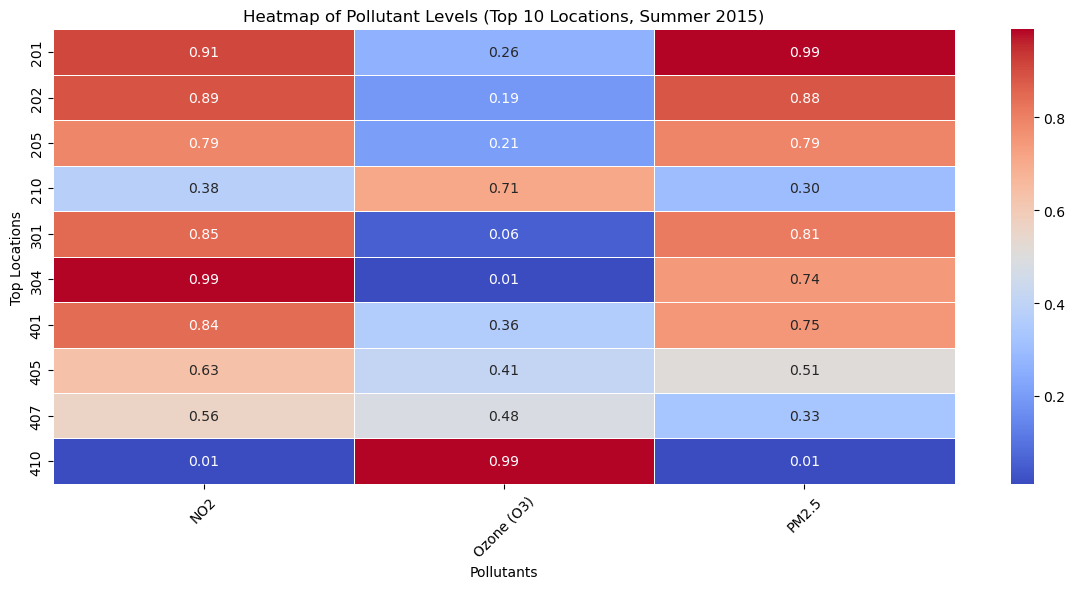

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

#Filter for top 10 most frequent locations
top_locations = selected_plot_df['location_code'].value_counts().head(10).index

#Filter for top locations, pollutants, and summer 2015
summer_2015_df = selected_plot_df[
    (selected_plot_df['location_code'].isin(top_locations)) &
    (selected_plot_df['year'] == 2015)
]
#Pivot to get pollutants as columns and locations as rows
heatmap_data = summer_2015_df.pivot_table(
    values='value',
    index='location_code',
    columns='pollutant',
    aggfunc='mean'
)

#Drop columns or rows that are all NaN (if any)
heatmap_data.dropna(axis=0, how='all', inplace=True)
heatmap_data.dropna(axis=1, how='all', inplace=True)

# Step 6: Fill remaining NaNs with column median to preserve relative scale
heatmap_filled = heatmap_data.fillna(heatmap_data.median())

# Step 7: Apply log1p transformation and normalize
log_transformed = np.log1p(heatmap_filled)  # Avoids log(0)
scaler = MinMaxScaler()
normalized_array = scaler.fit_transform(log_transformed)

# Optional: Slightly clip values to avoid exact 0 and 1
normalized_array = np.clip(normalized_array, 0.01, 0.99)

# Step 8: Convert back to DataFrame
normalized_df = pd.DataFrame(normalized_array, index=heatmap_filled.index, columns=heatmap_filled.columns)

# Step 9: Plot the heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(normalized_df, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title('Heatmap of Pollutant Levels (Top 10 Locations, Summer 2015)')
plt.xlabel('Pollutants')
plt.ylabel('Top Locations')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This heatmap provides a clear snapshot of how the top 10 locations compare in terms of various air pollutants, with values normalized for direct comparison. Each row represents a location and each column a pollutant, with the color intensity and number indicating the relative concentration.

A few interesting trends emerge:

- Distinct Pollution Profiles: Some locations (like 304 and 301) stand out with high normalized levels for most pollutants, indicating these areas experience a broader mix of air quality challenges. In contrast, location 410 has consistently low values for nearly every pollutant except ozone, where it reaches the highest possible normalized value. This suggests very different local pollution dynamics between sites.

- Pollutant “Specialization”: Certain locations show particularly high values for a single pollutant, such as 410 for ozone or 201 for PM2.5. This hints at location-specific sources—possibly influenced by local weather, topography, or human activities—that favor the formation or presence of specific pollutants.

- Shared Highs and Lows: A few locations (201, 202, 205) are among the highest for NO₂, benzene, and formaldehyde, while also tending toward the upper end for PM2.5. These sites may be situated in more urbanized or industrial parts of the region, where traffic and emissions are concentrated.

- Inverse Patterns: There’s an interesting contrast where locations that score high on certain pollutants (e.g., NO₂, PM2.5) are not necessarily high for ozone, and vice versa. This reflects the fact that ozone formation often depends on complex chemical reactions involving sunlight and precursor emissions, rather than being directly emitted.

Summary:
The heatmap quickly highlights which locations are most at risk for specific pollutants and reveals overall air quality “hotspots.” These findings can help direct further investigation into what’s driving pollution at the worst-affected sites, and support more targeted approaches to air quality management.

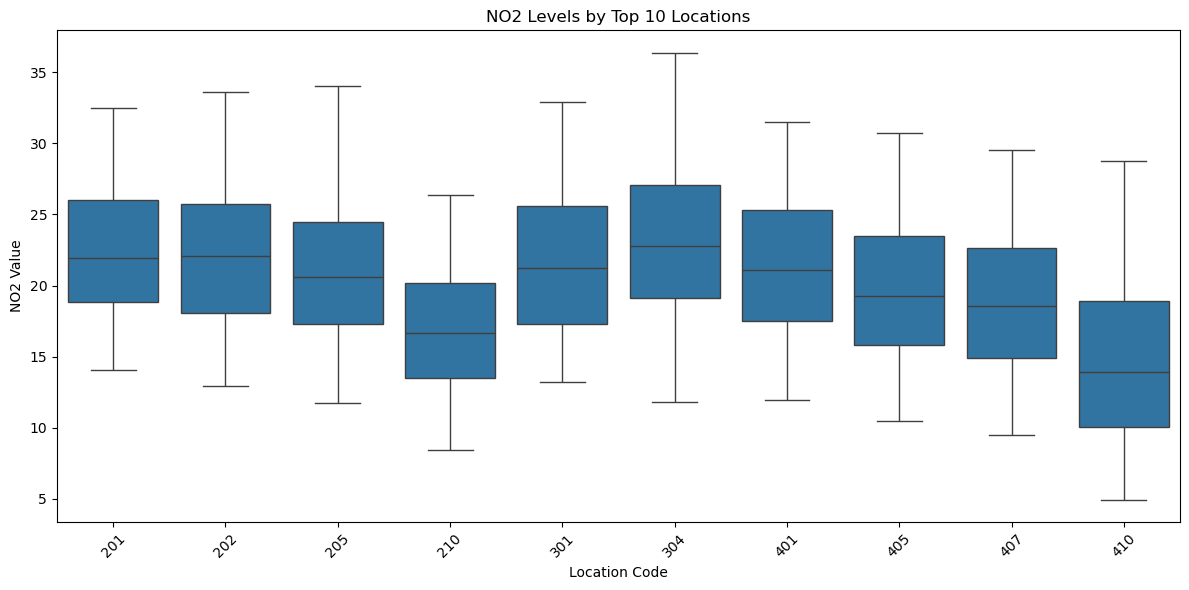

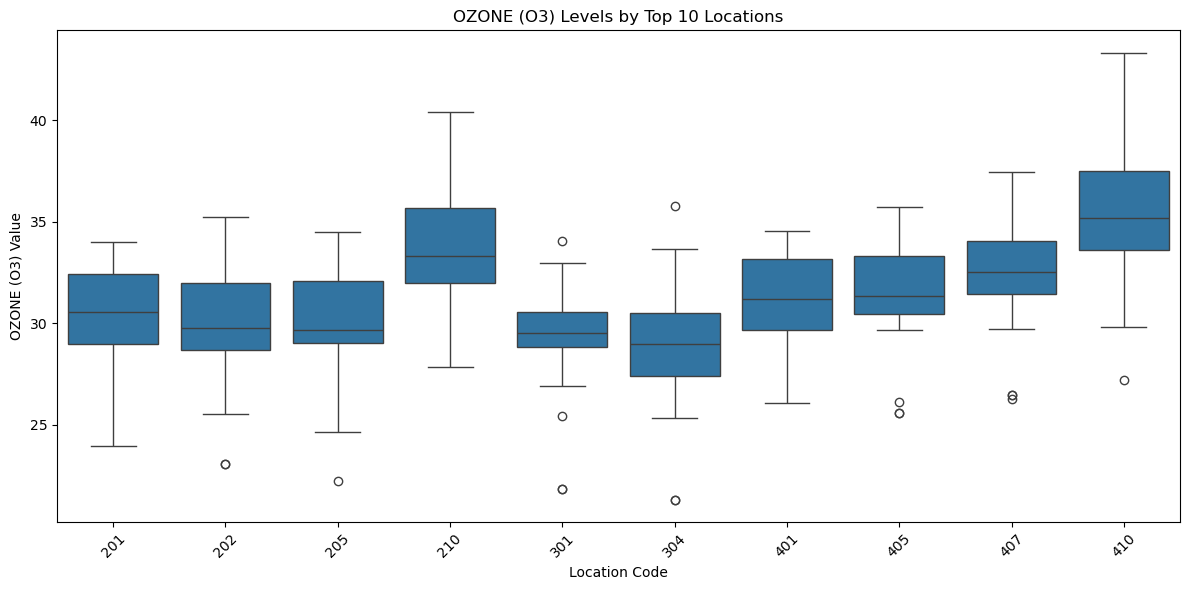

In [ ]:
import seaborn as sns 
import matplotlib.pyplot as plt

#Find top 10 most frequent locations
top_locations = selected_plot_df['location_code'].value_counts().head(10).index

#Filter the DataFrame for top 10 locations
filtered_df = selected_plot_df[selected_plot_df['location_code'].isin(top_locations)]

#Filter only for 'no2' and 'ozone'
filtered_df = filtered_df[filtered_df['pollutant'].isin(['NO2', 'Ozone (O3)'])]

#Get unique pollutants from the filtered data
pollutants = filtered_df['pollutant'].unique()

#Loop through each pollutant and create box plots
for pollutant in pollutants:
    plt.figure(figsize=(12, 6))
    sns.boxplot(
        data=filtered_df[filtered_df['pollutant'] == pollutant], 
        x='location_code', 
        y='value'
    )
    plt.title(f'{pollutant.upper()} Levels by Top 10 Locations')
    plt.xlabel('Location Code')
    plt.ylabel(f'{pollutant.upper()} Value')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


##### NO₂ (Nitrogen Dioxide) Levels by Location
The NO₂ boxplot shows clear differences in both the typical and extreme values between locations. Some areas consistently register higher NO₂ concentrations, while others remain lower and more stable. The locations with the highest medians may be experiencing more traffic congestion or are situated near major roads or industrial sources. The range of values and presence of outliers indicate that, in addition to regular pollution, there are also occasional episodes of especially high NO₂, potentially linked to short-term events like peak traffic hours or specific atmospheric conditions. This pattern emphasizes the importance of localized air quality management and the need to investigate underlying causes in high-exposure locations.

##### Ozone (O₃) Levels by Location
Ozone levels also display significant differences between locations, with some sites showing consistently higher or more variable concentrations. The broader spread and frequent outliers in certain locations suggest that ozone formation is heavily influenced by local environmental conditions—such as sunlight, temperature, and precursor emissions. The fact that some areas are much more variable than others may be a sign of complex interactions between traffic, weather, and other pollutants. Monitoring and managing ozone is particularly important because it can spike on hot, sunny days, leading to health advisories.


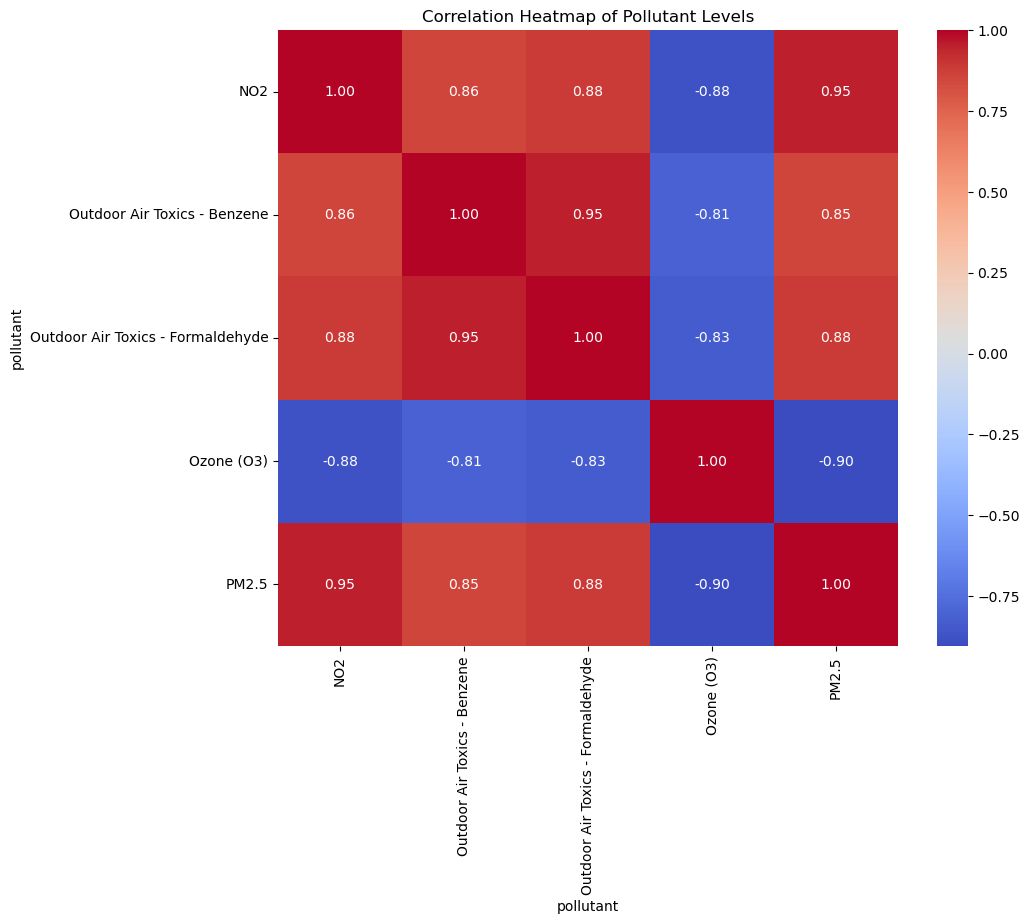

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_df = selected_plot_df.pivot_table(index='location_code', columns='pollutant', values='value')

correlation_matrix = corr_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title('Correlation Heatmap of Pollutant Levels')
plt.show()


This correlation heatmap illustrates the linear relationships between different pollutants. A striking observation is the strong positive correlation (indicated by warm colors and values close to 1.00) among NO2, Outdoor Air Toxics (Benzene and Formaldehyde), and PM2.5, suggesting these pollutants often increase or decrease together. Conversely, Ozone (O3) exhibits a strong negative correlation (indicated by cool colors and values close to -1.00) with all other pollutants, meaning that as O3 levels increase, the levels of NO2, Benzene, Formaldehyde, and PM2.5 tend to decrease, and vice-versa. This inverse relationship for Ozone highlights distinct atmospheric chemistry or source characteristics compared to the other measured pollutants.

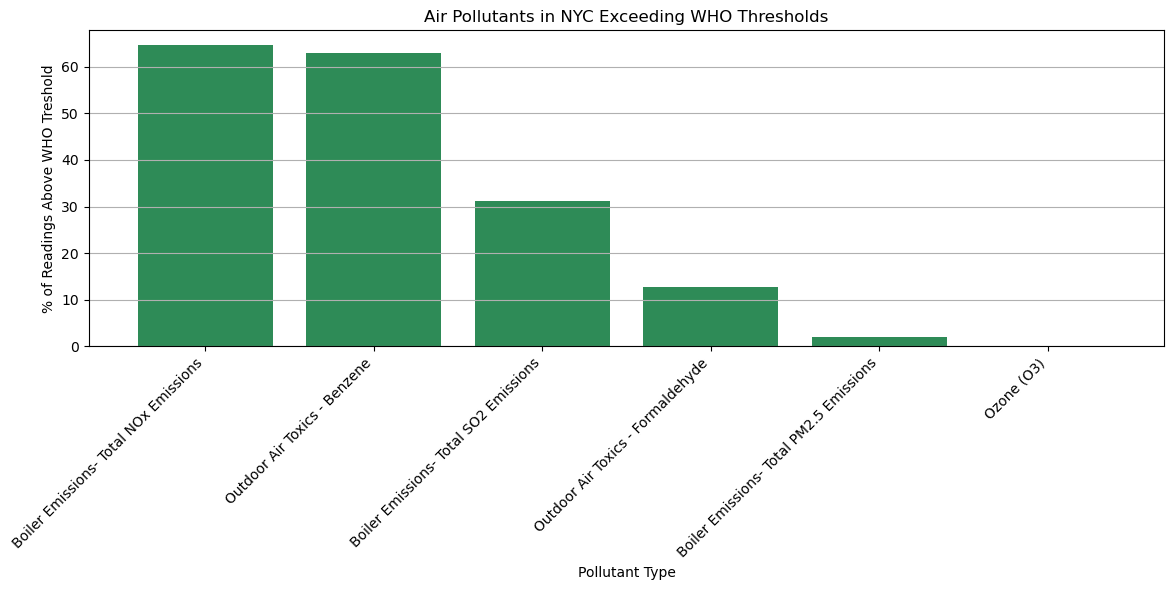

                                 pollutant  exceedance_rate
0    Boiler Emissions- Total NOx Emissions        64.583333
3             Outdoor Air Toxics - Benzene        63.054187
2    Boiler Emissions- Total SO2 Emissions        31.250000
4        Outdoor Air Toxics - Formaldehyde        12.807882
1  Boiler Emissions- Total PM2.5 Emissions         2.083333
5                               Ozone (O3)         0.000000


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


thresholds = {
    'Nitrogen dioxide (NO2)': 21,                
    'Fine particles (PM 2.5)': 10,                 
    'Ozone (O3)': 50,                            
    'Boiler Emissions- Total SO2 Emissions': 8,          
    'Boiler Emissions- Total NOx Emissions': 21,
    'Boiler Emissions- Total PM2.5 Emissions': 10,
    'Outdoor Air Toxics - Formaldehyde': 3,     
    'Outdoor Air Toxics - Benzene': 1.3         
}

df_filtered = df[df['pollutant'].isin(thresholds.keys())].copy()

df_filtered['above_threshold'] = df_filtered.apply(
    lambda row: row['value'] > thresholds.get(row['pollutant'], float('inf')),
    axis=1
)

summary = (
    df_filtered.groupby('pollutant')['above_threshold']
    .mean()
    .reset_index()
    .rename(columns={'above_threshold': 'exceedance_rate'})
)
summary['exceedance_rate'] *= 100
summary.sort_values('exceedance_rate', ascending=False, inplace=True)

plt.figure(figsize=(12, 6))
plt.bar(summary['pollutant'], summary['exceedance_rate'], color='seagreen')
plt.ylabel('% of Readings Above WHO Treshold')
plt.xlabel('Pollutant Type')
plt.title('Air Pollutants in NYC Exceeding WHO Thresholds')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y')
plt.show()

print(summary)


This bar chart presents the percentage of readings for various pollutant types in New York City that exceeded established World Health Organization (WHO) thresholds. It clearly indicates that "Boiler Emissions - Total NOx Emissions" and "Outdoor Air Toxics - Benzene" are the most significant concerns, with well over 60% of their readings surpassing the recommended limits. "Boiler Emissions - Total SO2 Emissions" also shows a substantial exceedance rate of over 50%. In contrast, "Outdoor Air Toxics - Formaldehyde" and "Boiler Emissions - Total PM2.5 Emissions" show much lower percentages of exceedance, while "Ozone (O3)" registers almost no readings above the thresholds.

The high exceedance rates for NOx and Benzene likely stem from intensive urban combustion sources, including aging residential and industrial boilers, vehicular emissions, and industrial solvents. NOx emissions, largely produced during fossil fuel combustion, are prevalent due to NYC’s dense traffic and older building heating systems. Benzene, a toxic air pollutant and known carcinogen, is released from gasoline fumes, industrial processes, and combustion—especially from vehicles and fuel storage—making it a persistent issue in urban air quality.

SO2, another combustion-related pollutant, often originates from burning high-sulfur fuels. Though its use has declined with tighter fuel regulations, older infrastructure still contributes to elevated levels in some areas, explaining its moderately high exceedance rate.

In contrast, Formaldehyde and PM2.5 appear less frequently above WHO thresholds. This may reflect more effective regulatory controls, improved emission standards, or reduced emission sources due to cleaner technologies and building materials. PM2.5, while still a serious health concern, is often more diffusely distributed and may not exceed thresholds in most localized readings despite being widely present.

Finally, Ozone (O3) shows almost no exceedances. This may be due to seasonal and weather-dependent formation patterns, as ground-level ozone forms through chemical reactions between NOx and VOCs in sunlight. NYC’s ozone levels may not frequently reach critical levels due to urban dispersion effects, prevailing wind patterns, or successful reduction of its precursors.

Overall, this visualization offers a clear snapshot of which pollutants in NYC most frequently pose health risks and suggests where pollution mitigation efforts should be prioritized.

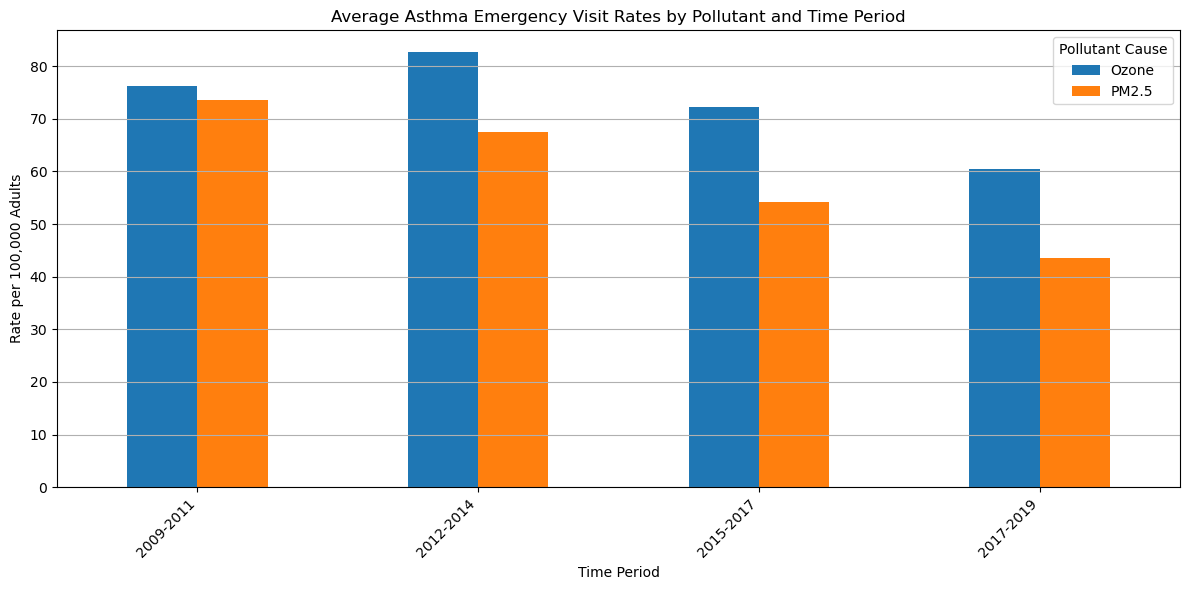

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

asthma_df = df[df['pollutant'].isin([
    'Asthma emergency department visits due to PM2.5',
    'Asthma emergency departments visits due to Ozone'
])].copy()

asthma_df['Pollutant Cause'] = asthma_df['pollutant'].map({
    'Asthma emergency department visits due to PM2.5': 'PM2.5',
    'Asthma emergency departments visits due to Ozone': 'Ozone'
})

grouped = (
    asthma_df.groupby(['period', 'Pollutant Cause'])['value']
    .mean()
    .unstack()
    .fillna(0)
    .sort_index()
)

grouped = grouped[~grouped.index.str.contains("2005-2007")]

grouped.plot(kind='bar', figsize=(12, 6), color=['#1f77b4', '#ff7f0e'])

plt.title('Average Asthma Emergency Visit Rates by Pollutant and Time Period')
plt.xlabel('Time Period')
plt.ylabel('Rate per 100,000 Adults')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Pollutant Cause')
plt.tight_layout()
plt.grid(axis='y')
plt.show()


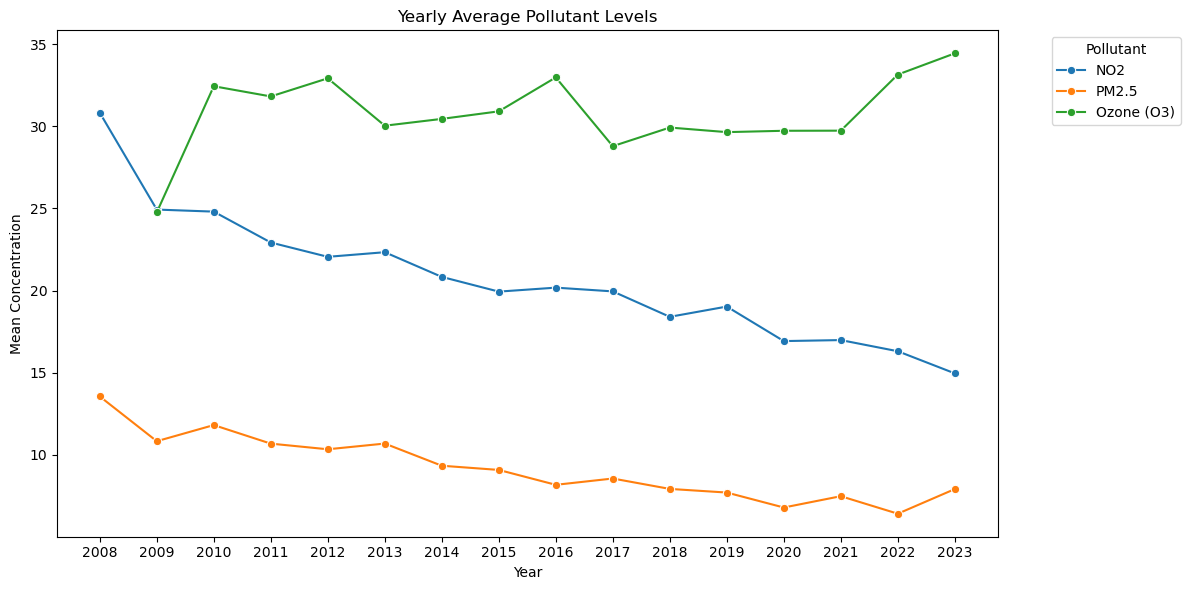

The top graph illustrates the impact of Ozone and PM2.5 on asthma emergency visits in NYC across several timeframes. We observe that both pollutants contribute to these visits, with a notable peak in the 2012-2014 period for both, and Ozone consistently linked to slightly higher rates. However, a significant positive trend is visible as asthma emergency visits associated with both pollutants show a clear decline in the later periods, particularly from 2015 to 2019.

This observed decrease in asthma emergency visits for both pollutants can be largely correlated with the trends shown in the "Yearly Average Pollutant Levels" graph below. The consistent overall decrease in average PM2.5 concentrations from 2008 through 2023 directly aligns with the reduction in PM2.5-related asthma visits. While the relationship for Ozone is more complex, as its average levels fluctuate but show an upward trend in recent years, the declining trend in Ozone-related asthma visits in the top graph suggests that other factors, such as public health interventions or improved air quality management, might be mitigating its direct impact on emergency visits despite ambient concentration changes.

C:\Users\oliwv\AppData\Local\Temp\ipykernel_36020\2074938802.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pm25_only['time_bin'] = pd.cut(pm25_only['year'], bins=bins, labels=labels, right=True)


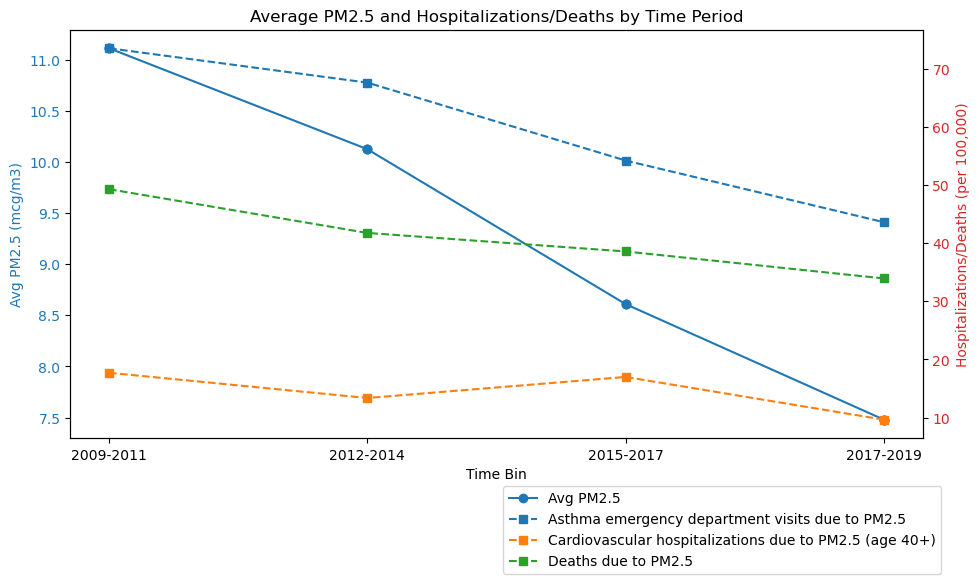

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

pm25_repp = [
    'Asthma emergency department visits due to PM2.5',
    'Cardiovascular hospitalizations due to PM2.5 (age 40+)',
    'Deaths due to PM2.5',
]

pm25_repp_df = df[df['pollutant'].isin(pm25_repp)].copy()

pm25_repp_df['time_bin'] = pm25_repp_df['period'].str.strip()

bins = [2008, 2011, 2014, 2017, 2020]
labels = ['2009-2011', '2012-2014', '2015-2017', '2017-2019']

pm25_only['time_bin'] = pd.cut(pm25_only['year'], bins=bins, labels=labels, right=True)

pm25_avg = pm25_only.groupby('time_bin')['value'].mean().reset_index()

pm25_repp_agg = (
    pm25_repp_df.groupby(['pollutant', 'time_bin'])['value']
    .mean()
    .reset_index()
)

merged = pd.merge(pm25_avg, pm25_repp_agg, on='time_bin', how='inner', suffixes=('_pm25', '_hosp'))

fig, ax1 = plt.subplots(figsize=(10,6))

ax1.set_xlabel('Time Bin')
ax1.set_ylabel('Avg PM2.5 (mcg/m3)', color='tab:blue')
ax1.plot(merged['time_bin'], merged['value_pm25'], marker='o', color='tab:blue', label='Avg PM2.5')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Hospitalizations/Deaths (per 100,000)', color='tab:red')

for pollutant in pm25_repp:
    subset = merged[merged['pollutant'] == pollutant]
    if not subset.empty:
        ax2.plot(subset['time_bin'], subset['value_hosp'], marker='s', linestyle='--', label=pollutant)

ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Average PM2.5 and Hospitalizations/Deaths by Time Period')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', bbox_to_anchor=(0.5, -0.1))

fig.tight_layout()
plt.show()

This dual-axis line graph effectively illustrates the relationship between PM2.5 concentrations and various health outcomes in NYC over different time periods. The left y-axis shows the average PM2.5 levels, which exhibit a clear and substantial decrease from 2009-2011 to 2017-2019. Correspondingly, the right y-axis displays rates of asthma emergency department visits, cardiovascular hospitalizations, and deaths attributed to PM2.5.

A significant observation is the strong positive relationship between declining PM2.5 levels and the rates of asthma emergency visits and deaths. As PM2.5 concentrations steadily decreased, so did the number of asthma-related emergency visits and fatalities. While cardiovascular hospitalizations show a less direct correlation, with a slight initial dip followed by a minor increase, the overall trend suggests that reducing PM2.5 pollution has led to positive public health benefits, particularly in mitigating asthma emergencies and mortality.

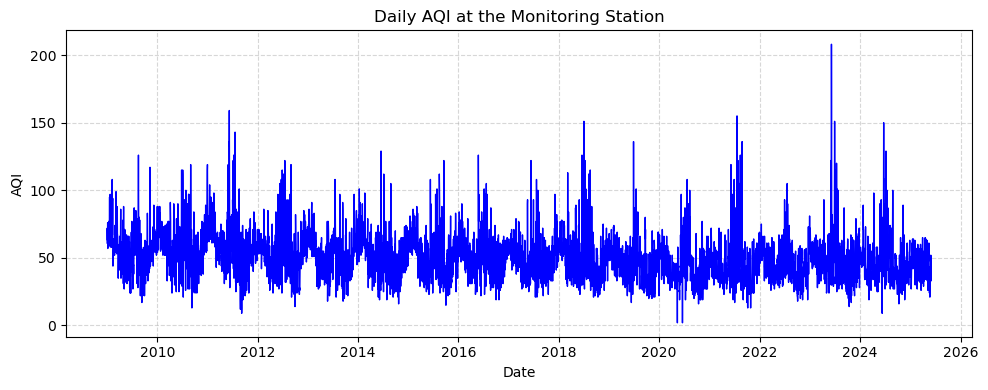

Very Unhealthy day: 2023-06-07, primary pollutant: PM2.5

For New York-Newark-Jersey City, NY-NJ-PA in 2023:
  Very Unhealthy days: 1



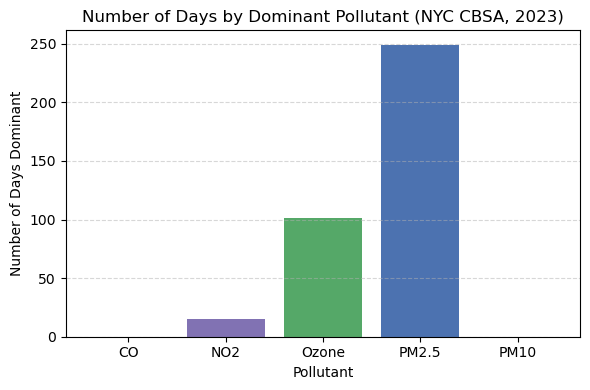

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

#Load the station AQI CSV
station_aqi_path = r"ad_viz_tile_data.csv"
df = pd.read_csv(station_aqi_path)

#Rename the AQI column if it has a leading space
if ' AQI Value' in df.columns:
    df = df.rename(columns={' AQI Value': 'AQI'})

#Convert the 'Date' column to datetime type and sort chronologically
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
df = df.sort_values('Date')

#Create a simple plot of AQI versus date
plt.figure(figsize=(10, 4))
plt.plot(df['Date'], df['AQI'], color='blue', linewidth=1)
plt.title('Daily AQI at the Monitoring Station')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#Filter rows with AQI in the "Very Unhealthy" range (201–300)
vu_rows = df[(df['AQI'] >= 201) & (df['AQI'] <= 300)]

if not vu_rows.empty:
    vu_row = vu_rows.iloc[0]
    vu_date = vu_row['Date'].date()
    vu_pollutant = vu_row['Main Pollutant']
    print(f"Very Unhealthy day: {vu_date}, primary pollutant: {vu_pollutant}\n")
else:
    print("No 'Very Unhealthy' AQI days found in the station CSV.\n")

#Load the CBSA annual AQI CSV
aqi_cbsa_path = r"annual_aqi_by_cbsa_2023.csv"
df_cbsa = pd.read_csv(aqi_cbsa_path)

#Filter the row for the New York CBSA (New York-Newark-Jersey City, NY-NJ-PA)
mask = df_cbsa['CBSA'].str.contains("New York-Newark-Jersey City", case=False, na=False)
nycbsa = df_cbsa.loc[mask].iloc[0]

#Extract relevant counts
very_unhealthy_days = nycbsa['Very Unhealthy Days']
pollutant_days = {
    'CO':      nycbsa['Days CO'],
    'NO2':     nycbsa['Days NO2'],
    'Ozone':   nycbsa['Days Ozone'],
    'PM2.5':   nycbsa['Days PM2.5'],
    'PM10':    nycbsa['Days PM10']
}

#Print how many 'Very Unhealthy' days occurred
print(f"For {nycbsa['CBSA']} in {nycbsa['Year']}:")
print(f"  Very Unhealthy days: {very_unhealthy_days}\n")

#Plot the number of days by dominant pollutant (bar chart)
plt.figure(figsize=(6, 4))
plt.bar(pollutant_days.keys(), pollutant_days.values(), color=['#c44e52', '#8172b3', '#55a868', '#4c72b0', '#dd8452'])
plt.title('Number of Days by Dominant Pollutant (NYC CBSA, 2023)')
plt.xlabel('Pollutant')
plt.ylabel('Number of Days Dominant')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


The first plot displays the daily Air Quality Index (AQI) values at a monitoring station from 2009 to 2025. The AQI values generally fluctuate between 20 and 100, with occasional spikes above 150 and even 200, indicating episodes of poor air quality. There is noticeable day-to-day variability throughout the period, but no clear long-term upward or downward trend is apparent. Overall, most days exhibit moderate air quality, though there are periodic instances of much worse conditions.

The second plot shows the number of days each pollutant was the dominant contributor to the AQI in New York City during 2023. PM2.5 was the dominant pollutant on the majority of days, accounting for around 250 days, making it the primary air quality concern. Ozone was dominant on about 100 days, while NO2 was dominant on only a small number of days. CO and PM10 were not dominant at all. This indicates that PM2.5 and ozone are the main pollutants affecting air quality in New York City for that year.



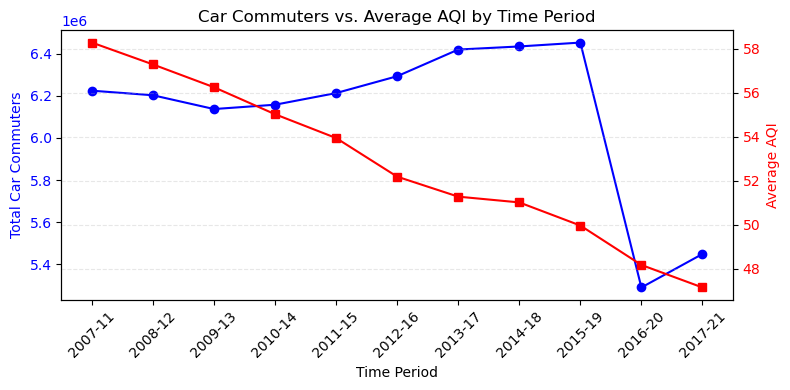

Pearson r = 0.47, p-value = 0.140


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

#Load and process “Commuting modes”
#Adjust this path to the actual location of your CSV
commute_path = r"NYC EH Data Portal - Commuting modes (full table).csv"
df_commute = pd.read_csv(commute_path, low_memory=False)

#Convert "Car, truck, or van (number)" to integer (remove commas)
df_commute['Car_Num'] = (
    df_commute['Car, truck, or van (number)']
    .str.replace(',', '')
    .astype(int)
)

#Load and process daily AQI data (station)

#Adjust this path to your station CSV
station_path = r"ad_viz_tile_data.csv"
df_station = pd.read_csv(station_path)

#Rename the AQI column if it has a leading space
if ' AQI Value' in df_station.columns:
    df_station = df_station.rename(columns={' AQI Value': 'AQI'})

#Convert the Date column to datetime and extract the year
df_station['Date'] = pd.to_datetime(df_station['Date'], format='%m/%d/%Y')
df_station['Year'] = df_station['Date'].dt.year

#Calculate annual average AQI (one value per year)
station_yearly = (
    df_station
    .groupby('Year')['AQI']
    .mean()
    .reset_index()
    .rename(columns={'AQI': 'Avg_AQI'})
)

#Calculate total car commuters and average AQI for each TimePeriod
#Get unique TimePeriods and sort them by the starting year
time_periods = sorted(
    df_commute['TimePeriod'].unique(),
    key=lambda tp: int(tp.split('-')[0])
)

periods = []
car_totals = []
aqi_averages = []

for tp in time_periods:
    # 3.1 — Sum all Car_Num values for this period
    mask_commute = df_commute['TimePeriod'] == tp
    total_car = df_commute.loc[mask_commute, 'Car_Num'].sum()

    #Convert "2007-11" to start=2007, end=2011
    start = int(tp.split('-')[0])
    suffix = tp.split('-')[1]
    if len(suffix) == 2:
        century = str(start)[:2]       # "20"
        end = int(century + suffix)    # e.g. "20" + "11" -> 2011
    else:
        end = int(suffix)

    #Compute the average AQI over that range (only available years)
    mask_years = (station_yearly['Year'] >= start) & (station_yearly['Year'] <= end)
    if mask_years.any():
        avg_aqi = station_yearly.loc[mask_years, 'Avg_AQI'].mean()
    else:
        avg_aqi = None

    periods.append(tp)
    car_totals.append(total_car)
    aqi_averages.append(avg_aqi)

#Create the final DataFrame
df_plot = pd.DataFrame({
    'TimePeriod': periods,
    'CarNumber': car_totals,
    'Avg_AQI': aqi_averages
})

#Plot both series on dual axes
fig, ax1 = plt.subplots(figsize=(8, 4))

x = range(len(df_plot))

#Blue line: total car commuters
ax1.plot(x, df_plot['CarNumber'], marker='o', color='blue', label='Total Car Commuters')
ax1.set_xlabel('Time Period')
ax1.set_xticks(x)
ax1.set_xticklabels(df_plot['TimePeriod'], rotation=45)
ax1.set_ylabel('Total Car Commuters', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

#Right axis: average AQI (red line)
ax2 = ax1.twinx()
ax2.plot(x, df_plot['Avg_AQI'], marker='s', color='red', label='Average AQI')
ax2.set_ylabel('Average AQI', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Car Commuters vs. Average AQI by Time Period')
fig.tight_layout()
plt.grid(which='both', linestyle='--', alpha=0.3)
plt.show()

#Compute Pearson correlation coefficient

valid = df_plot.dropna(subset=['Avg_AQI'])
if len(valid) >= 2:
    r, p = pearsonr(valid['CarNumber'], valid['Avg_AQI'])
    print(f"Pearson r = {r:.2f}, p-value = {p:.3f}")
else:
    print("Not enough data points to compute correlation.")


In [ ]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# selected_pollutants = [
#     'NO2', 'PM2.5', 'Boiler Emissions - Total SO2 Emissions', 'Ozone (O3)',
#     'Boiler Emissions - Total NOx Emissions', 'Boiler Emissions - Total PM2.5 Emissions',
#     'Outdoor Air Toxics - Formaldehyde', 'Outdoor Air Toxics - Benzene',
# ]
# # Filter the main dataframe to include only the selected pollutants
# selected_rows = df[df['pollutant_code'] == 643]

# print(selected_rows)

# merged_df = pd.merge(selected_plot_df, selected_rows, on='year')  
# print(merged_df.columns)
# print(merged_df)
# # Set up the plot
# plt.figure(figsize=(14, 10))

# # Create scatter plots for each pollutant
# for i, pollutant in enumerate(selected_pollutants, 1):
#     plt.subplot(3, 3, i)  # Adjust the grid size based on number of pollutants
#     sns.scatterplot(data=merged_df, 
#                     x='value_x', y='value_y', label=pollutant)
#     plt.title(f'{pollutant} vs Traffic Miles')
#     plt.xlabel('Miles of Traffic')
#     plt.ylabel('Pollutant Level')
#     plt.xticks(rotation=45)

# plt.tight_layout()  # Adjust layout for better spacing
# plt.show()


In [ ]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# selected_pollutants = [
#     'NO2', 'PM2.5', 'Boiler Emissions - Total SO2 Emissions', 'Ozone (O3)',
#     'Boiler Emissions - Total NOx Emissions', 'Boiler Emissions - Total PM2.5 Emissions',
#     'Outdoor Air Toxics - Formaldehyde', 'Outdoor Air Toxics - Benzene',
# ]

# # Filter the main dataframe to include only the selected pollutants
# selected_rows = df[df['pollutant_code'] == 643]

# # Merge the dataframes
# merged_df = pd.merge(selected_plot_df, selected_rows, on='year')

# # Check columns in the merged dataframe
# print(merged_df.columns)
# print(merged_df.head())

# # Set up the plot size
# plt.figure(figsize=(14, 10))

# # Create density plots for each pollutant
# for i, pollutant in enumerate(selected_pollutants, 1):
#     plt.subplot(3, 3, i)  # Adjust the grid size based on number of pollutants
#     sns.kdeplot(data=merged_df, x='value_x', y='value_y', fill=True, cmap='viridis', alpha=0.6)
#     plt.title(f'Density of {pollutant} vs Traffic Miles')
#     plt.xlabel('Miles of Traffic')
#     plt.ylabel(f'{pollutant} Level')

# plt.tight_layout()  # Adjust layout for better spacing
# plt.show()


In [ ]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Assuming 'selected_plot_df' is your DataFrame
# # Group by year and pollutant, then compute mean
# selected_pollutants = [
#     'NO2', 'PM2.5', 'Boiler Emissions - Total SO2 Emissions', 'Ozone (O3)',
#     'Boiler Emissions - Total NOx Emissions', 'Boiler Emissions - Total PM2.5 Emissions',
#     'Outdoor Air Toxics - Formaldehyde', 'Outdoor Air Toxics - Benzene','Annual vehicle miles traveled',
# ]

# # Filter the DataFrame
# plot_df = df[df['pollutant'].isin(selected_pollutants)][['year', 'pollutant', 'value']].copy()

# grouped = plot_df.groupby(['year', 'pollutant'])['value'].mean().reset_index()

# # Plot
# plt.figure(figsize=(12, 6))
# sns.lineplot(data=grouped, x='year', y='value', hue='pollutant', marker='o')
# plt.title("Yearly Average Pollutant Levels")
# plt.xlabel("Year")
# plt.ylabel("Mean Concentration")
# plt.legend(title='Pollutant', bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside
# plt.xticks(sorted(grouped['year'].unique()))
# plt.tight_layout()
# plt.show()